###Setup paths and mount Drive

In [1]:
!pip install -q -U bitsandbytes>=0.46.1

In [2]:
import os
import re
import json
import time
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

from google.colab import drive
drive.mount('/content/drive')

# Folder to save new Mistral-on-Qwen outputs
PHASE1_DIR = "/content/drive/MyDrive/Colab Notebooks/MistralGEval2"

# Qwen test file you want to reuse
TEST_FILE = "/content/drive/MyDrive/Colab Notebooks/MistralGEval2/test.jsonl"

# New output files
BASE_PRED_FILE = os.path.join(PHASE1_DIR, "mistral_base_on_qwen_test.jsonl")
FT_PRED_FILE   = os.path.join(PHASE1_DIR, "mistral_ft_on_qwen_test.jsonl")

# Base model + LoRA adapter path
BASE_MODEL = "mistralai/Mistral-7B-Instruct-v0.2"
ADAPTER_PATH = os.path.join(PHASE1_DIR, "calendar_extraction_model_final")

print("TEST_FILE:", TEST_FILE)
print("BASE_PRED_FILE:", BASE_PRED_FILE)
print("FT_PRED_FILE:", FT_PRED_FILE)
print("ADAPTER_PATH:", ADAPTER_PATH)
print("Test file exists?", os.path.exists(TEST_FILE))
print("Adapter path exists?", os.path.exists(ADAPTER_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TEST_FILE: /content/drive/MyDrive/Colab Notebooks/MistralGEval2/test.jsonl
BASE_PRED_FILE: /content/drive/MyDrive/Colab Notebooks/MistralGEval2/mistral_base_on_qwen_test.jsonl
FT_PRED_FILE: /content/drive/MyDrive/Colab Notebooks/MistralGEval2/mistral_ft_on_qwen_test.jsonl
ADAPTER_PATH: /content/drive/MyDrive/Colab Notebooks/MistralGEval2/calendar_extraction_model_final
Test file exists? True
Adapter path exists? True


###JSON helpers

In [3]:
def read_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

def parse_json_from_text(text):
    if isinstance(text, dict):
        return text, True

    text = str(text).strip()

    if "```json" in text:
        text = text.split("```json")[1].split("```")[0].strip()
    elif "```" in text:
        text = text.split("```")[1].split("```")[0].strip()

    match = re.search(r"\{.*\}", text, re.DOTALL)
    if match:
        text = match.group(0)

    try:
        return json.loads(text), True
    except:
        return {}, False

###Extract email and GT from Qwen test rows

In [4]:
def extract_qwen_email_and_gt(example):
    email = [m["content"] for m in example["messages"] if m["role"] == "user"][0]
    gt_text = [m["content"] for m in example["messages"] if m["role"] == "assistant"][0]
    gt_json, _ = parse_json_from_text(gt_text)
    return email, gt_json

###Map Qwen GT to Mistral-compatible schema

In [5]:
def qwen_gt_to_mistral_gt(gt):
    is_meeting = gt.get("is_meeting", True)

    if not is_meeting:
        return {
            "title": None,
            "start_utc": None,
            "end_utc": None,
            "location": None,
            "attendees": [],
            "notes": None
        }

    return {
        "title": gt.get("title"),
        "start_utc": gt.get("start_time"),
        "end_utc": gt.get("end_time"),
        "location": gt.get("location"),
        "attendees": gt.get("attendees", []),
        "notes": None
    }

def build_prompt_from_qwen_example(example):
    email, _ = extract_qwen_email_and_gt(example)

    instruction = (
        "Extract meeting details as JSON with keys: "
        "title, start_utc, end_utc, location, attendees, notes."
    )

    prompt = f"{instruction}\n\nHere is the email:\n\n{email}"
    return f"[INST] {prompt.strip()} [/INST]"

###Load and inspect the reused Qwen test file

In [6]:
qwen_test_data = read_jsonl(TEST_FILE)

print("Total rows:", len(qwen_test_data))

sample_email, sample_gt = extract_qwen_email_and_gt(qwen_test_data[0])
sample_mistral_gt = qwen_gt_to_mistral_gt(sample_gt)

print("\nEMAIL:\n", sample_email[:1000])
print("\nQWEN GT:\n", json.dumps(sample_gt, indent=2)[:1000])
print("\nMISTRAL-MAPPED GT:\n", json.dumps(sample_mistral_gt, indent=2))

Total rows: 709

EMAIL:
 Subject: ferc meeting on northeast rto

----- Forwarded by Sarah Novosel/Corp/Enron on 07/11/2001 04:54 PM -----

	Sarah Novosel
	07/11/2001 04:24 PM
		 
		 To: Kevin M Presto/Enron@EnronXGate, Mark Dana Davis/HOU/ECT@ECT, Jeff 
Ader/HOU/EES@EES, Edward D Baughman/Enron@EnronXGate, Joe 
Gordon/Enron@EnronXGate, Janelle Scheuer/Enron@EnronXGate, mbrown9@enron.com, 
Mark Bernstein/HOU/EES@EES, John Llodra/Enron@EnronXGate, George 
Wood/Enron@EnronXGate, Paul J Broderick/Enron@EnronXGate, Jason 
Thompkins/Enron@EnronXGate, Mason Hamlin/Enron@EnronXGate, Robert 
Stalford/Enron@EnronXGate, Tom May/Enron@EnronXGate, Gautam 
Gupta/Enron@EnronXGate, Narsimha Misra/Enron@EnronXGate, Steve 
Montovano/NA/Enron@Enron, Garrett Tripp/Enron@EnronXGate, Berney C 
Aucoin/Enron@EnronXGate, Jason Thompkins/Enron@EnronXGate, Rob 
Wheeler/Enron@EnronXGate, Rogers Herndon/Enron@EnronXGate, Jim 
Meyn/Enron@EnronXGate, Aleck Dadson/Enron@EnronXGate, Daniel 
Allegretti/Enron@EnronXGate

###Load tokenizer and bitsandbytes config

In [7]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print("Tokenizer loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizer loaded.


###Load BASE Mistral

In [8]:
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
)
base_model.eval()

print("Base Mistral loaded.")

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Base Mistral loaded.


###Run BASE Mistral on Qwen test set

In [9]:
base_rows = []

for ex in tqdm(qwen_test_data, desc="Generating base predictions on Qwen test"):
    email, qwen_gt = extract_qwen_email_and_gt(ex)
    gt_for_mistral = qwen_gt_to_mistral_gt(qwen_gt)

    prompt = build_prompt_from_qwen_example(ex)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(base_model.device)

    with torch.no_grad():
        outputs = base_model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    gen_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    raw_output = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()
    predicted_json, valid = parse_json_from_text(raw_output)

    base_rows.append({
        "input": email,
        "predicted_json": predicted_json,
        "ground_truth_json": gt_for_mistral,
        "raw_model_output": raw_output,
        "pred_valid": valid
    })

with open(BASE_PRED_FILE, "w", encoding="utf-8") as f:
    for row in base_rows:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print(f"Saved {len(base_rows)} rows to: {BASE_PRED_FILE}")


Generating base predictions on Qwen test: 100%|██████████| 709/709 [2:32:01<00:00, 12.87s/it]

Saved 709 rows to: /content/drive/MyDrive/Colab Notebooks/MistralGEval2/mistral_base_on_qwen_test.jsonl


In [10]:
print("Base rows generated:", len(base_rows))
print("Base output file exists:", os.path.exists(BASE_PRED_FILE))
print("Sample base row:")
print(json.dumps(base_rows[0], indent=2)[:2000])

Base rows generated: 709
Base output file exists: True
Sample base row:
{
  "input": "Subject: ferc meeting on northeast rto\n\n----- Forwarded by Sarah Novosel/Corp/Enron on 07/11/2001 04:54 PM -----\n\n\tSarah Novosel\n\t07/11/2001 04:24 PM\n\t\t \n\t\t To: Kevin M Presto/Enron@EnronXGate, Mark Dana Davis/HOU/ECT@ECT, Jeff \nAder/HOU/EES@EES, Edward D Baughman/Enron@EnronXGate, Joe \nGordon/Enron@EnronXGate, Janelle Scheuer/Enron@EnronXGate, mbrown9@enron.com, \nMark Bernstein/HOU/EES@EES, John Llodra/Enron@EnronXGate, George \nWood/Enron@EnronXGate, Paul J Broderick/Enron@EnronXGate, Jason \nThompkins/Enron@EnronXGate, Mason Hamlin/Enron@EnronXGate, Robert \nStalford/Enron@EnronXGate, Tom May/Enron@EnronXGate, Gautam \nGupta/Enron@EnronXGate, Narsimha Misra/Enron@EnronXGate, Steve \nMontovano/NA/Enron@Enron, Garrett Tripp/Enron@EnronXGate, Berney C \nAucoin/Enron@EnronXGate, Jason Thompkins/Enron@EnronXGate, Rob \nWheeler/Enron@EnronXGate, Rogers Herndon/Enron@EnronXGate, Jim \nMeyn

###Load FINE-TUNED Mistral (Base + LoRA)

In [11]:
from peft import PeftModel

ft_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
)
ft_model = PeftModel.from_pretrained(ft_model, ADAPTER_PATH)
ft_model.eval()

print("Fine-tuned Mistral loaded.")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Fine-tuned Mistral loaded.


###Run FINE-TUNED Mistral on Qwen test set

In [12]:
ft_rows = []

for ex in tqdm(qwen_test_data, desc="Generating fine-tuned predictions on Qwen test"):
    email, qwen_gt = extract_qwen_email_and_gt(ex)
    gt_for_mistral = qwen_gt_to_mistral_gt(qwen_gt)

    prompt = build_prompt_from_qwen_example(ex)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(ft_model.device)

    with torch.no_grad():
        outputs = ft_model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    gen_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    raw_output = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()
    predicted_json, valid = parse_json_from_text(raw_output)

    ft_rows.append({
        "input": email,
        "predicted_json": predicted_json,
        "ground_truth_json": gt_for_mistral,
        "raw_model_output": raw_output,
        "pred_valid": valid
    })

with open(FT_PRED_FILE, "w", encoding="utf-8") as f:
    for row in ft_rows:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print(f"Saved {len(ft_rows)} rows to: {FT_PRED_FILE}")

Generating fine-tuned predictions on Qwen test: 100%|██████████| 709/709 [3:13:12<00:00, 16.35s/it]

Saved 709 rows to: /content/drive/MyDrive/Colab Notebooks/MistralGEval2/mistral_ft_on_qwen_test.jsonl


###Align base and fine-tuned outputs

In [13]:
base_rows = read_jsonl(BASE_PRED_FILE)
ft_rows = read_jsonl(FT_PRED_FILE)

print("base_rows:", len(base_rows))
print("ft_rows:", len(ft_rows))

aligned_rows = []
for b, f in zip(base_rows, ft_rows):
    aligned_rows.append({
        "email": b["input"],
        "ground_truth": b["ground_truth_json"],
        "base_prediction": b["predicted_json"],
        "base_raw_output": b["raw_model_output"],
        "base_valid": b.get("pred_valid", True),
        "ft_prediction": f["predicted_json"],
        "ft_raw_output": f["raw_model_output"],
        "ft_valid": f.get("pred_valid", True),
    })

print("aligned_rows:", len(aligned_rows))
print(json.dumps(aligned_rows[0], indent=2)[:2000])

base_rows: 709
ft_rows: 709
aligned_rows: 709
{
  "email": "Subject: ferc meeting on northeast rto\n\n----- Forwarded by Sarah Novosel/Corp/Enron on 07/11/2001 04:54 PM -----\n\n\tSarah Novosel\n\t07/11/2001 04:24 PM\n\t\t \n\t\t To: Kevin M Presto/Enron@EnronXGate, Mark Dana Davis/HOU/ECT@ECT, Jeff \nAder/HOU/EES@EES, Edward D Baughman/Enron@EnronXGate, Joe \nGordon/Enron@EnronXGate, Janelle Scheuer/Enron@EnronXGate, mbrown9@enron.com, \nMark Bernstein/HOU/EES@EES, John Llodra/Enron@EnronXGate, George \nWood/Enron@EnronXGate, Paul J Broderick/Enron@EnronXGate, Jason \nThompkins/Enron@EnronXGate, Mason Hamlin/Enron@EnronXGate, Robert \nStalford/Enron@EnronXGate, Tom May/Enron@EnronXGate, Gautam \nGupta/Enron@EnronXGate, Narsimha Misra/Enron@EnronXGate, Steve \nMontovano/NA/Enron@Enron, Garrett Tripp/Enron@EnronXGate, Berney C \nAucoin/Enron@EnronXGate, Jason Thompkins/Enron@EnronXGate, Rob \nWheeler/Enron@EnronXGate, Rogers Herndon/Enron@EnronXGate, Jim \nMeyn/Enron@EnronXGate, Aleck D

###Evaluation helper functions

In [14]:
def norm_str(x):
    if x is None:
        return None
    return str(x).strip().lower()

def norm_attendees(x):
    if not x:
        return []

    cleaned = []
    for v in x:
        if isinstance(v, dict):
            if "email" in v and v["email"]:
                cleaned.append(str(v["email"]).strip().lower())
            elif "name" in v and v["name"]:
                cleaned.append(str(v["name"]).strip().lower())
        else:
            s = str(v).strip().lower()
            if s:
                cleaned.append(s)
    return sorted(cleaned)

def attendee_f1(pred_attendees, gt_attendees):
    p = set(norm_attendees(pred_attendees))
    g = set(norm_attendees(gt_attendees))

    if len(g) == 0 and len(p) == 0:
        return 1.0
    if len(g) == 0 or len(p) == 0:
        return 0.0

    inter = len(p & g)
    prec = inter / len(p)
    rec = inter / len(g)
    return 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

def safe_dict(x):
    return x if isinstance(x, dict) else {}

###Quick heuristic evaluation on common fields

In [15]:
def field_accuracy_mistral_on_qwen(pred, gt):
    pred = safe_dict(pred)
    gt = safe_dict(gt)

    fields = ["title", "start_utc", "end_utc", "location"]
    scores = []

    for field in fields:
        scores.append(1.0 if norm_str(pred.get(field)) == norm_str(gt.get(field)) else 0.0)

    scores.append(attendee_f1(pred.get("attendees", []), gt.get("attendees", [])))
    return float(np.mean(scores))

summary_rows = []

for row in aligned_rows:
    gt = safe_dict(row["ground_truth"])
    b = safe_dict(row["base_prediction"])
    f = safe_dict(row["ft_prediction"])

    b_score = field_accuracy_mistral_on_qwen(b, gt)
    f_score = field_accuracy_mistral_on_qwen(f, gt)

    if f_score > b_score:
        winner = "fine_tuned"
    elif b_score > f_score:
        winner = "base"
    else:
        winner = "tie"

    summary_rows.append({
        "base_score": b_score,
        "ft_score": f_score,
        "winner": winner
    })

print("Base mean:", np.mean([r["base_score"] for r in summary_rows]))
print("FT mean:", np.mean([r["ft_score"] for r in summary_rows]))
print("\nWinner counts:")
print(pd.Series([r["winner"] for r in summary_rows]).value_counts())

Base mean: 0.4718225983388184
FT mean: 0.43508930079537467

Winner counts:
base          289
fine_tuned    275
tie           145
Name: count, dtype: int64


###Build G-Eval prompt on common fields only

In [16]:
def build_geval_prompt(email, gt, base_pred, ft_pred):
    return f"""
You are an expert evaluator for extracting meeting details from emails.

Evaluate two model outputs against the ground truth.

EMAIL:
{email}

GROUND TRUTH:
{json.dumps(gt, indent=2)}

BASE MODEL OUTPUT:
{json.dumps(base_pred, indent=2)}

FINE-TUNED MODEL OUTPUT:
{json.dumps(ft_pred, indent=2)}

Evaluate only these common fields:
- title
- start_utc
- end_utc
- location
- attendees

Scoring guidance:
- Be fair and practical rather than overly strict.
- Minor wording differences should not be penalized heavily.
- Partial correctness should receive partial credit.
- If both outputs are similarly usable, return "tie".

Score each model from 1 to 5 on:
1. field_accuracy
2. completeness
3. consistency
4. overall_quality

Return ONLY valid JSON in this format:
{{
  "base": {{
    "field_accuracy": 1,
    "completeness": 1,
    "consistency": 1,
    "overall_quality": 1
  }},
  "fine_tuned": {{
    "field_accuracy": 1,
    "completeness": 1,
    "consistency": 1,
    "overall_quality": 1
  }},
  "winner": "base" or "fine_tuned" or "tie",
  "reason": "one short sentence"
}}
"""

In [17]:
def parse_judge_json(text):
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if match:
        text = match.group(0)
    return json.loads(text)

###Run G-Eval on 100-sample subset

In [18]:
from openai import OpenAI
import os

os.environ["OPENAI_API_KEY"] = "your_API_key"

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

JUDGE_MODEL = "gpt-4o-mini"

In [19]:
subset = aligned_rows[:100]
llm_geval_results = []

for i, row in enumerate(tqdm(subset, desc="Running Mistral-on-Qwen G-Eval")):
    prompt = build_geval_prompt(
        row["email"],
        row["ground_truth"],
        row["base_prediction"],
        row["ft_prediction"]
    )

    try:
        resp = client.chat.completions.create(
            model=JUDGE_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0
        )

        parsed = parse_judge_json(resp.choices[0].message.content)

        llm_geval_results.append({
            "index": i,
            "judge_result": parsed
        })

    except Exception as e:
        llm_geval_results.append({
            "index": i,
            "judge_result": None,
            "error": str(e)
        })

    time.sleep(0.2)

print("Done:", len(llm_geval_results))

Running Mistral-on-Qwen G-Eval: 100%|██████████| 100/100 [03:52<00:00,  2.33s/it]

Done: 100


###Aggregate and plot G-Eval results

            Metric  Base  Fine-tuned
0   field_accuracy  2.34        3.25
1     completeness  1.99        2.62
2      consistency  2.28        3.22
3  overall_quality  2.10        2.98

Winner counts:
fine_tuned    46
base          39
tie           15
Name: count, dtype: int64


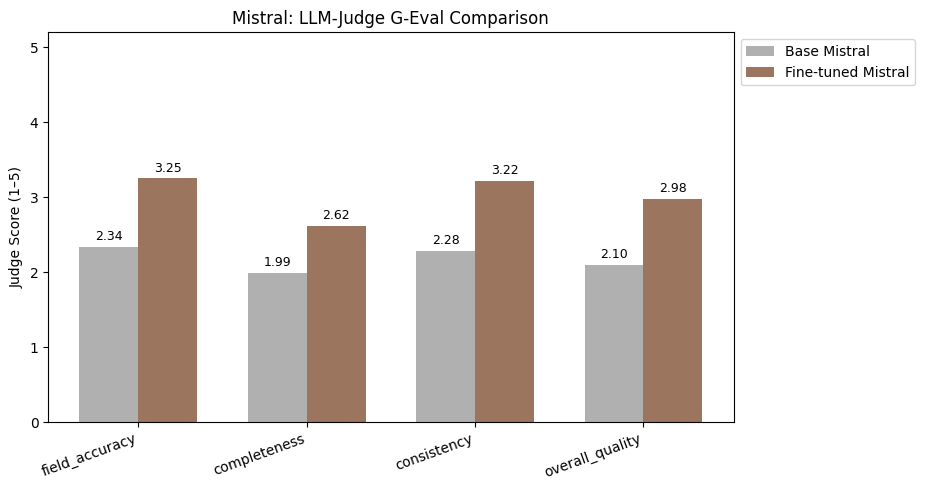

In [20]:
dimensions = [
    "field_accuracy",
    "completeness",
    "consistency",
    "overall_quality"
]

valid_rows = [r for r in llm_geval_results if r.get("judge_result") is not None]

base_summary = {}
ft_summary = {}

for d in dimensions:
    base_summary[d] = np.mean([r["judge_result"]["base"][d] for r in valid_rows])
    ft_summary[d] = np.mean([r["judge_result"]["fine_tuned"][d] for r in valid_rows])

winner_counts = pd.Series(
    [r["judge_result"]["winner"] for r in valid_rows]
).value_counts()

summary_df = pd.DataFrame({
    "Metric": dimensions,
    "Base": [round(base_summary[d], 3) for d in dimensions],
    "Fine-tuned": [round(ft_summary[d], 3) for d in dimensions],
})

print(summary_df)
print("\nWinner counts:")
print(winner_counts)

import matplotlib.pyplot as plt

labels = summary_df["Metric"].tolist()
base_vals = summary_df["Base"].tolist()
ft_vals = summary_df["Fine-tuned"].tolist()

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(11, 5))

bars1 = plt.bar(x - width/2, base_vals, width, label="Base Mistral", color="#b0b0b0")
bars2 = plt.bar(x + width/2, ft_vals, width, label="Fine-tuned Mistral", color="#9c755f")

plt.xticks(x, labels, rotation=20, ha="right")
plt.ylim(0, 5.2)
plt.ylabel("Judge Score (1–5)")
plt.title("Mistral: LLM-Judge G-Eval Comparison")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.05,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

###Combine Two charts GEval (Mistral Vs Qwen)

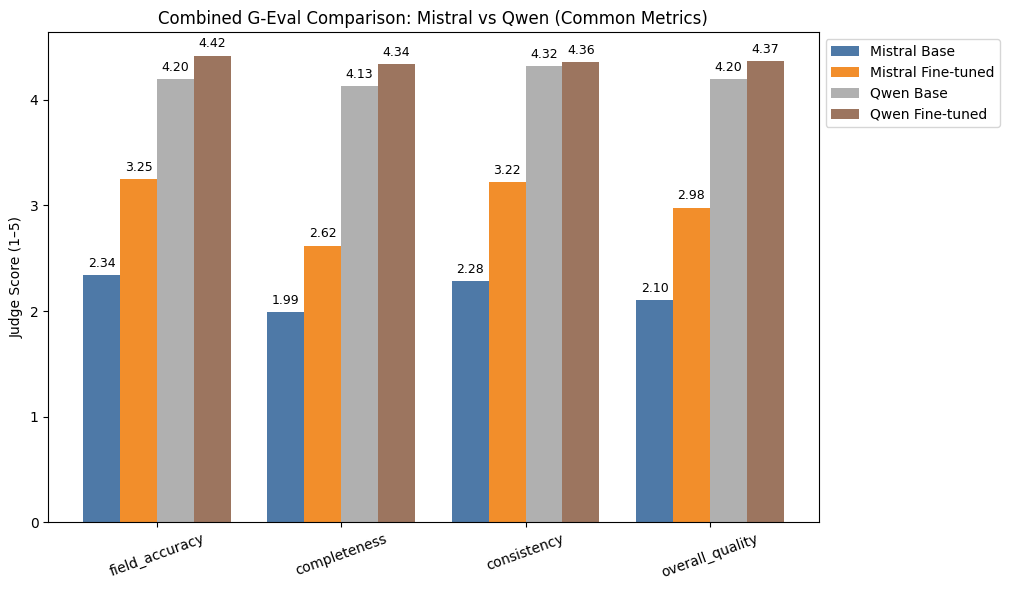

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Common metrics
metrics = ["field_accuracy", "completeness", "consistency", "overall_quality"]

# Mistral on Qwen test set
mistral_base = [2.34, 1.99, 2.28, 2.10]
mistral_ft   = [3.25, 2.62, 3.22, 2.98]

# Qwen
qwen_base = [4.20, 4.13, 4.32, 4.20]
qwen_ft   = [4.42, 4.34, 4.36, 4.37]

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(12, 6))

b1 = plt.bar(x - 1.5*width, mistral_base, width, label="Mistral Base", color="#4e79a7")
b2 = plt.bar(x - 0.5*width, mistral_ft, width, label="Mistral Fine-tuned", color="#f28e2b")
b3 = plt.bar(x + 0.5*width, qwen_base, width, label="Qwen Base", color="#b0b0b0")
b4 = plt.bar(x + 1.5*width, qwen_ft, width, label="Qwen Fine-tuned", color="#9c755f")

plt.xticks(x, metrics, rotation=20)
plt.ylabel("Judge Score (1–5)")
plt.title("Combined G-Eval Comparison: Mistral vs Qwen (Common Metrics)")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.05,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()